# GliomaGate results

This notebook loads the trained weights in `models/` and the 32 held-out slices in `data/test/`. Training itself is `python scripts/train.py`; the loss curves are in `models/train_log.json`.

## Setup

Weights: `models/segmenter.joblib` + LoRA adapters. Held-out cases: `data/test/` (32 slices).

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

ROOT = Path.cwd() if (Path.cwd() / 'app').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from app.segment import load_segmenter, predict_mask_mlp, mean_tumor_dice, image_findings
from app.lora_extract import load_lora, extract
from app.rag import GuidelineIndex
from app.ground import assemble_ledger
from app.synth import load_case, load_manifest
from app.main import overlay_rgb
from app.eval_harness import run_harness

MODELS = ROOT / 'models'
TEST = ROOT / 'data' / 'test'
FIGS = ROOT / 'docs' / 'figures'
mlp, head = load_segmenter(MODELS / 'segmenter.joblib')
lora = load_lora(MODELS)
cases = []
for meta in load_manifest(TEST):
    img, labels, m = load_case(TEST, meta['case_id'])
    rec = dict(m); rec['image']=img; rec['labels']=labels
    cases.append(rec)
print(f'loaded {len(cases)} held-out cases from {TEST}')
print('segmenter:', type(mlp).__name__, 'LoRA fields:', list(lora))
log = json.loads((MODELS / 'train_log.json').read_text())
print('MLP iterations:', log['segmenter']['n_iter'], 'final CE:', round(log['segmenter']['final_loss'], 4))
print('MLP train Dice:', round(log['segmenter']['train_dice'], 3))
print('LoRA train acc:', {k: round(v, 3) for k, v in log['lora']['train_field_acc'].items()})
print('LoRA test acc:', {k: round(v, 3) for k, v in log['lora']['test_field_acc'].items()})

loaded 32 held-out cases from C:\Users\Parisa\.cursor\githubbyc\gliomagate\data\test
segmenter: MLPClassifier LoRA fields: ['laterality', 'lobe', 'grade', 'enhancement', 'symptom']
MLP iterations: 160 final CE: 0.079
MLP train Dice: 0.863
LoRA train acc: {'laterality': 0.988, 'lobe': 0.5, 'grade': 0.812, 'enhancement': 0.938, 'symptom': 0.512}
LoRA test acc: {'laterality': 1.0, 'lobe': 0.312, 'grade': 0.656, 'enhancement': 0.906, 'symptom': 0.219}


## Training curves

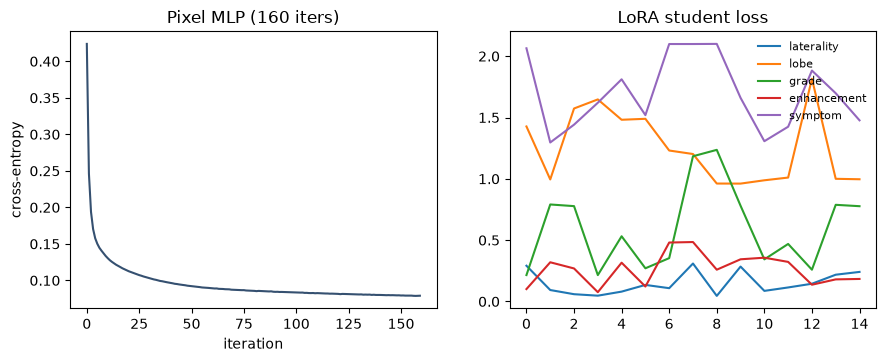

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
axes[0].plot(log['segmenter']['loss_curve'], color='#355070')
axes[0].set_title(f'Pixel MLP ({log["segmenter"]["n_iter"]} iters)')
axes[0].set_xlabel('iteration'); axes[0].set_ylabel('cross-entropy')
for field, curve in log['lora']['loss_curves'].items():
    axes[1].plot(curve, label=field)
axes[1].set_title('LoRA student loss'); axes[1].legend(frameon=False, fontsize=8)
plt.show()

## 1. What a case looks like

Synthetic T1-post-contrast-like slice: skull ring, bias field, enhancing core (label 2) and edema halo (label 1). The paired note is a neuro-oncology consult. Laterality in this generator is image-left = patient-left.

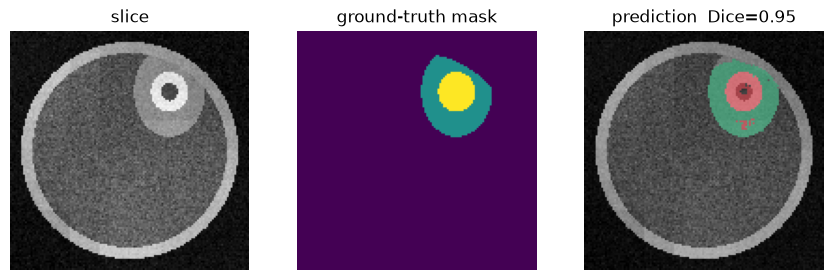

Neuro-oncology. Chief complaint is word-finding difficulty. There is a right-sided frontal mass. The lesion shows avid gadolinium uptake with a necrotic center. This is a high-grade pattern, likely GBM. Please discuss at tumor board. IDH and MGMT pending.


In [3]:
rec = cases[2]
pred = predict_mask_mlp(mlp, rec['image'])
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.4))
ax[0].imshow(rec['image'], cmap='gray'); ax[0].set_title('slice'); ax[0].axis('off')
ax[1].imshow(rec['labels'], cmap='viridis', vmin=0, vmax=2); ax[1].set_title('ground-truth mask'); ax[1].axis('off')
ax[2].imshow(overlay_rgb(rec['image'], pred)); ax[2].set_title(f'prediction  Dice={mean_tumor_dice(pred, rec["labels"]):.2f}'); ax[2].axis('off')
plt.show()
print(rec['note'])

## 2. Segmentation gallery (held-out)

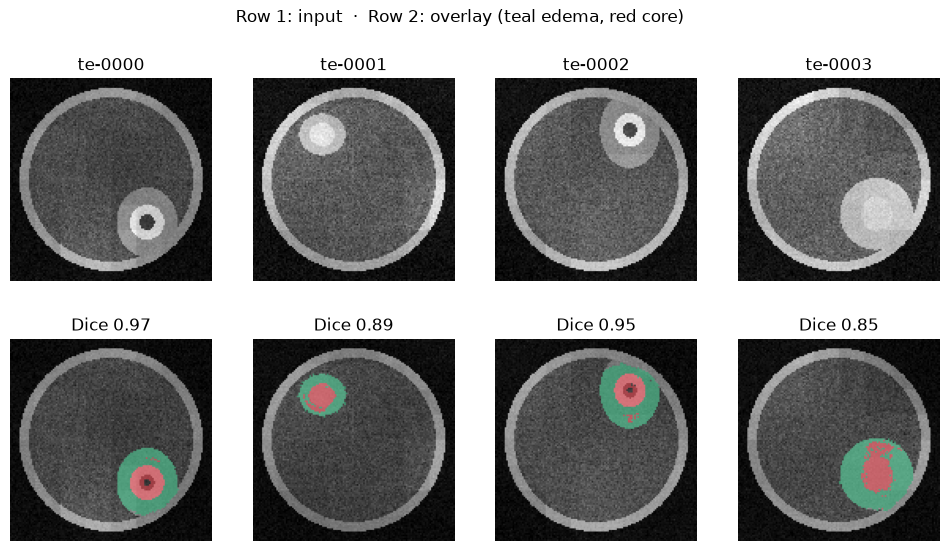

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6.2))
for i, rec in enumerate(cases[:4]):
    pred = predict_mask_mlp(mlp, rec['image'])
    axes[0, i].imshow(rec['image'], cmap='gray')
    axes[0, i].set_title(rec['case_id'])
    axes[0, i].axis('off')
    axes[1, i].imshow(overlay_rgb(rec['image'], pred))
    axes[1, i].set_title(f'Dice {mean_tumor_dice(pred, rec["labels"]):.2f}')
    axes[1, i].axis('off')
fig.suptitle('Row 1: input  ·  Row 2: overlay (teal edema, red core)')
plt.show()

## 3. Dice distribution

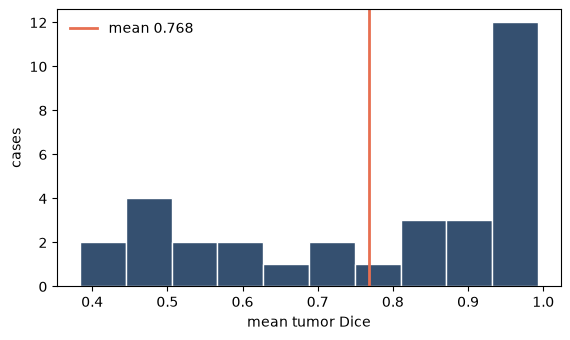

n=32  mean=0.768  p10=0.459  p90=0.986


In [5]:
dices = [mean_tumor_dice(predict_mask_mlp(mlp, c['image']), c['labels']) for c in cases]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(dices, bins=10, color='#355070', edgecolor='white')
ax.axvline(np.mean(dices), color='#e76f51', lw=2, label=f'mean {np.mean(dices):.3f}')
ax.set_xlabel('mean tumor Dice'); ax.set_ylabel('cases'); ax.legend(frameon=False)
plt.show()
print(f'n={len(dices)}  mean={np.mean(dices):.3f}  p10={np.percentile(dices,10):.3f}  p90={np.percentile(dices,90):.3f}')

## 4. Structured extraction + evidence ledger

Each field is tagged `image`, `retrieval`, or `ungrounded`. Grade is not allowed to come from the slice alone.

In [6]:
rec = cases[2]
pred = predict_mask_mlp(mlp, rec['image'])
findings = image_findings(pred)
extracted = extract(lora, rec['note'], findings)
index = GuidelineIndex()
hits = index.search(index.query_for_case(rec['note'], findings, extracted), k=4)
ledger = assemble_ledger(extracted, findings, hits)
print('NOTE:\n', rec['note'], '\n')
print(json.dumps(ledger, indent=2, default=str))
print('\nRETRIEVED:')
for h in hits:
    print(f'  {h.score:.3f}  {h.title}')

NOTE:
 Neuro-oncology. Chief complaint is word-finding difficulty. There is a right-sided frontal mass. The lesion shows avid gadolinium uptake with a necrotic center. This is a high-grade pattern, likely GBM. Please discuss at tumor board. IDH and MGMT pending. 

{
  "fields": {
    "laterality": {
      "value": "right",
      "confidence": 0.938,
      "provenance": "image",
      "evidence": [
        "mask centroid is on the right half of the slice",
        "supported by retrieved guideline span"
      ]
    },
    "lobe": {
      "value": "temporal",
      "confidence": 0.276,
      "provenance": "retrieval",
      "evidence": [
        "supported by retrieved guideline span"
      ]
    },
    "grade": {
      "value": "4",
      "confidence": 0.494,
      "provenance": "retrieval",
      "evidence": [
        "supported by retrieved guideline span"
      ]
    },
    "enhancement": {
      "value": "yes",
      "confidence": 0.676,
      "provenance": "image",
      "evidence"

## 5. Full harness (32 cases)

### Scores

{
  "dice": 0.7681846256408018,
  "field_acc": {
    "laterality": 1.0,
    "lobe": 0.3125,
    "grade": 0.65625,
    "enhancement": 0.90625,
    "symptom": 0.21875
  },
  "field_acc_mean": 0.61875,
  "ndcg5": 0.8045199347938826,
  "recall5": 0.8125,
  "grounded_fraction": 0.8625,
  "contradiction_rate": 0.0,
  "ablation": {
    "full_field_acc": 0.61875,
    "no_image_field_acc": 0.5562499999999999,
    "no_rag_grounded_fraction": 0.34375
  }
}


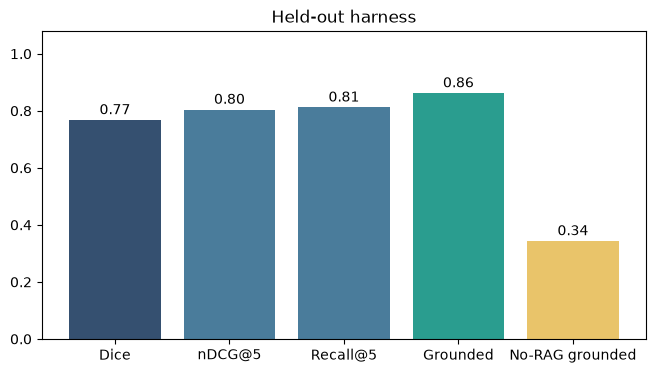

In [7]:
result = run_harness(cases, mlp, lora)
metrics = result.as_dict()
display(Markdown('### Scores'))
print(json.dumps(metrics, indent=2))
fig, ax = plt.subplots(figsize=(7.8, 4.0))
keys = ['Dice', 'nDCG@5', 'Recall@5', 'Grounded', 'No-RAG grounded']
vals = [metrics['dice'], metrics['ndcg5'], metrics['recall5'], metrics['grounded_fraction'], metrics['ablation']['no_rag_grounded_fraction']]
ax.bar(keys, vals, color=['#355070','#4a7c9b','#4a7c9b','#2a9d8f','#e9c46a'])
ax.set_ylim(0, 1.08); ax.set_title('Held-out harness')
for i,v in enumerate(vals):
    ax.text(i, v+0.02, f'{v:.2f}', ha='center')
plt.show()

### Ablation

Turning off retrieval drops how many fields we can support with a source. Segmentation and the note still run; the ledger just has less to cite.

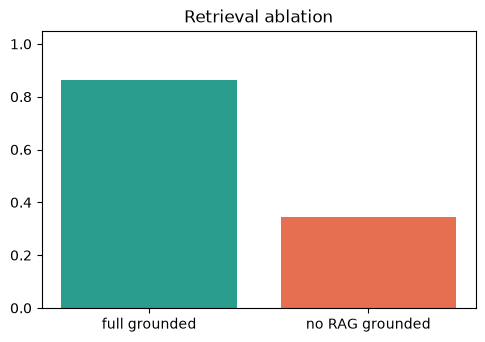

In [8]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.bar(['full grounded', 'no RAG grounded'],
       [metrics['grounded_fraction'], metrics['ablation']['no_rag_grounded_fraction']],
       color=['#2a9d8f','#e76f51'])
ax.set_ylim(0,1.05); ax.set_title('Retrieval ablation')
plt.show()

## 6. Latency

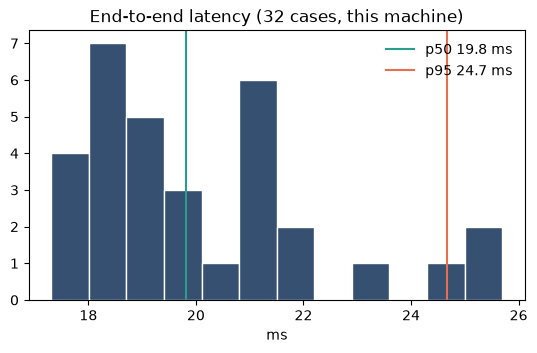

p50=19.81 ms  p95=24.67 ms  mean=20.13 ms
saved bench.json {
  "n": 80,
  "p50_ms": 29.02,
  "p95_ms": 35.52,
  "mean_ms": 29.59,
  "throughput_rps_serial": 33.8,
  "cloud_run_list_usd_per_infer_at_p95_1vcpu": 1e-06,
  "notes": "Measured in-process via TestClient on this machine. Not a 40 rps load-test on GPU. Cost is list-price Cloud Run CPU time at measured p95, no egress."
}


In [9]:
import time
lat = []
for rec in cases:
    t0 = time.perf_counter()
    pred = predict_mask_mlp(mlp, rec['image'])
    f = image_findings(pred)
    ex = extract(lora, rec['note'], f)
    ht = index.search(index.query_for_case(rec['note'], f, ex), k=4)
    assemble_ledger(ex, f, ht)
    lat.append((time.perf_counter()-t0)*1000)
lat.sort()
p50, p95 = lat[len(lat)//2], lat[int(0.95*(len(lat)-1))]
fig, ax = plt.subplots(figsize=(6.4, 3.5))
ax.hist(lat, bins=12, color='#355070', edgecolor='white')
ax.axvline(p50, color='#2a9d8f', label=f'p50 {p50:.1f} ms')
ax.axvline(p95, color='#e76f51', label=f'p95 {p95:.1f} ms')
ax.set_xlabel('ms'); ax.legend(frameon=False); ax.set_title('End-to-end latency (32 cases, this machine)')
plt.show()
print(f'p50={p50:.2f} ms  p95={p95:.2f} ms  mean={np.mean(lat):.2f} ms')
bench = json.loads((MODELS/'bench.json').read_text())
print('saved bench.json', json.dumps(bench, indent=2))

## Notes

Slices are synthetic (`app/synth.py`), so Dice is not a BraTS score. Extraction uses the trained LoRA adapters, not a keyword lookup.

Figures saved under `docs/figures/`:

ablation.png


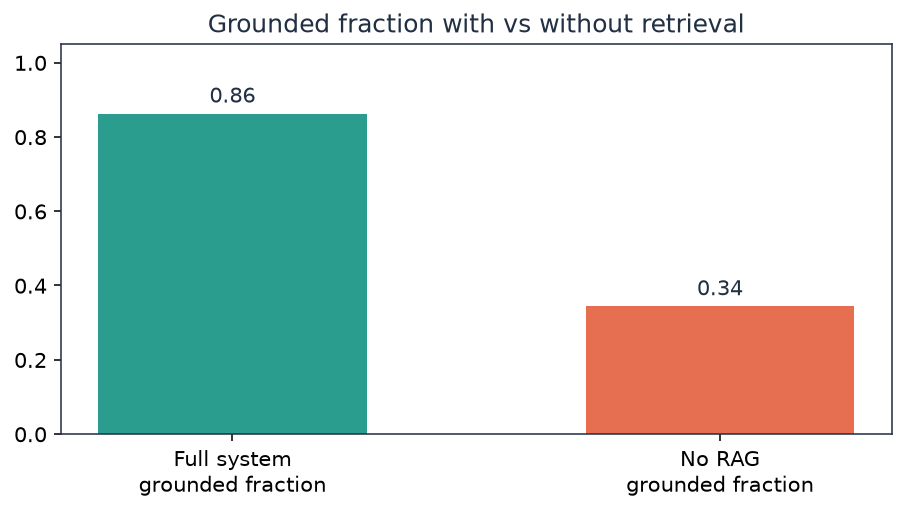

dice_hist.png


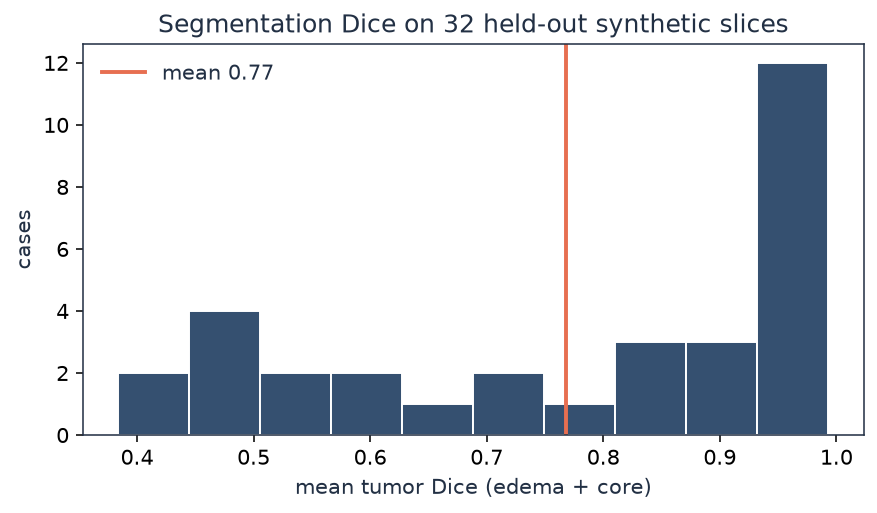

field_acc.png


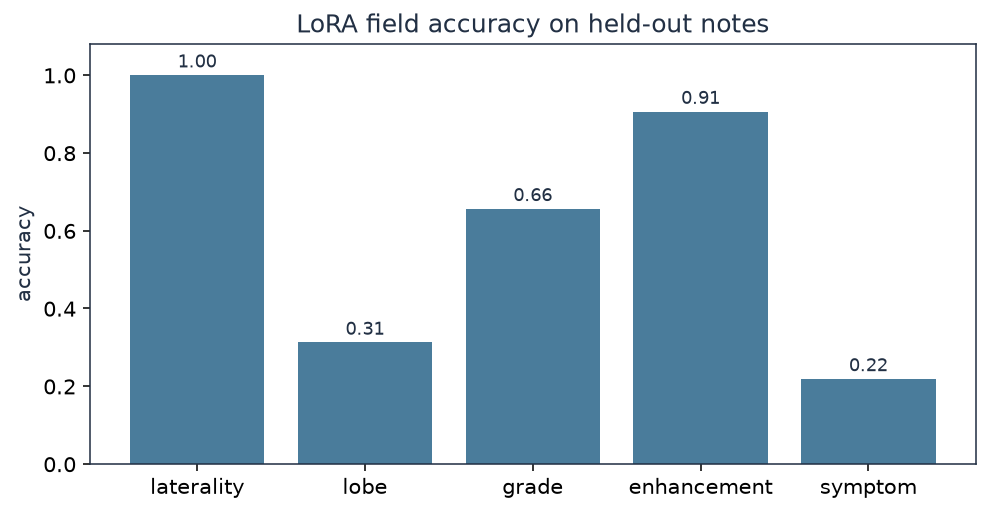

gallery.png


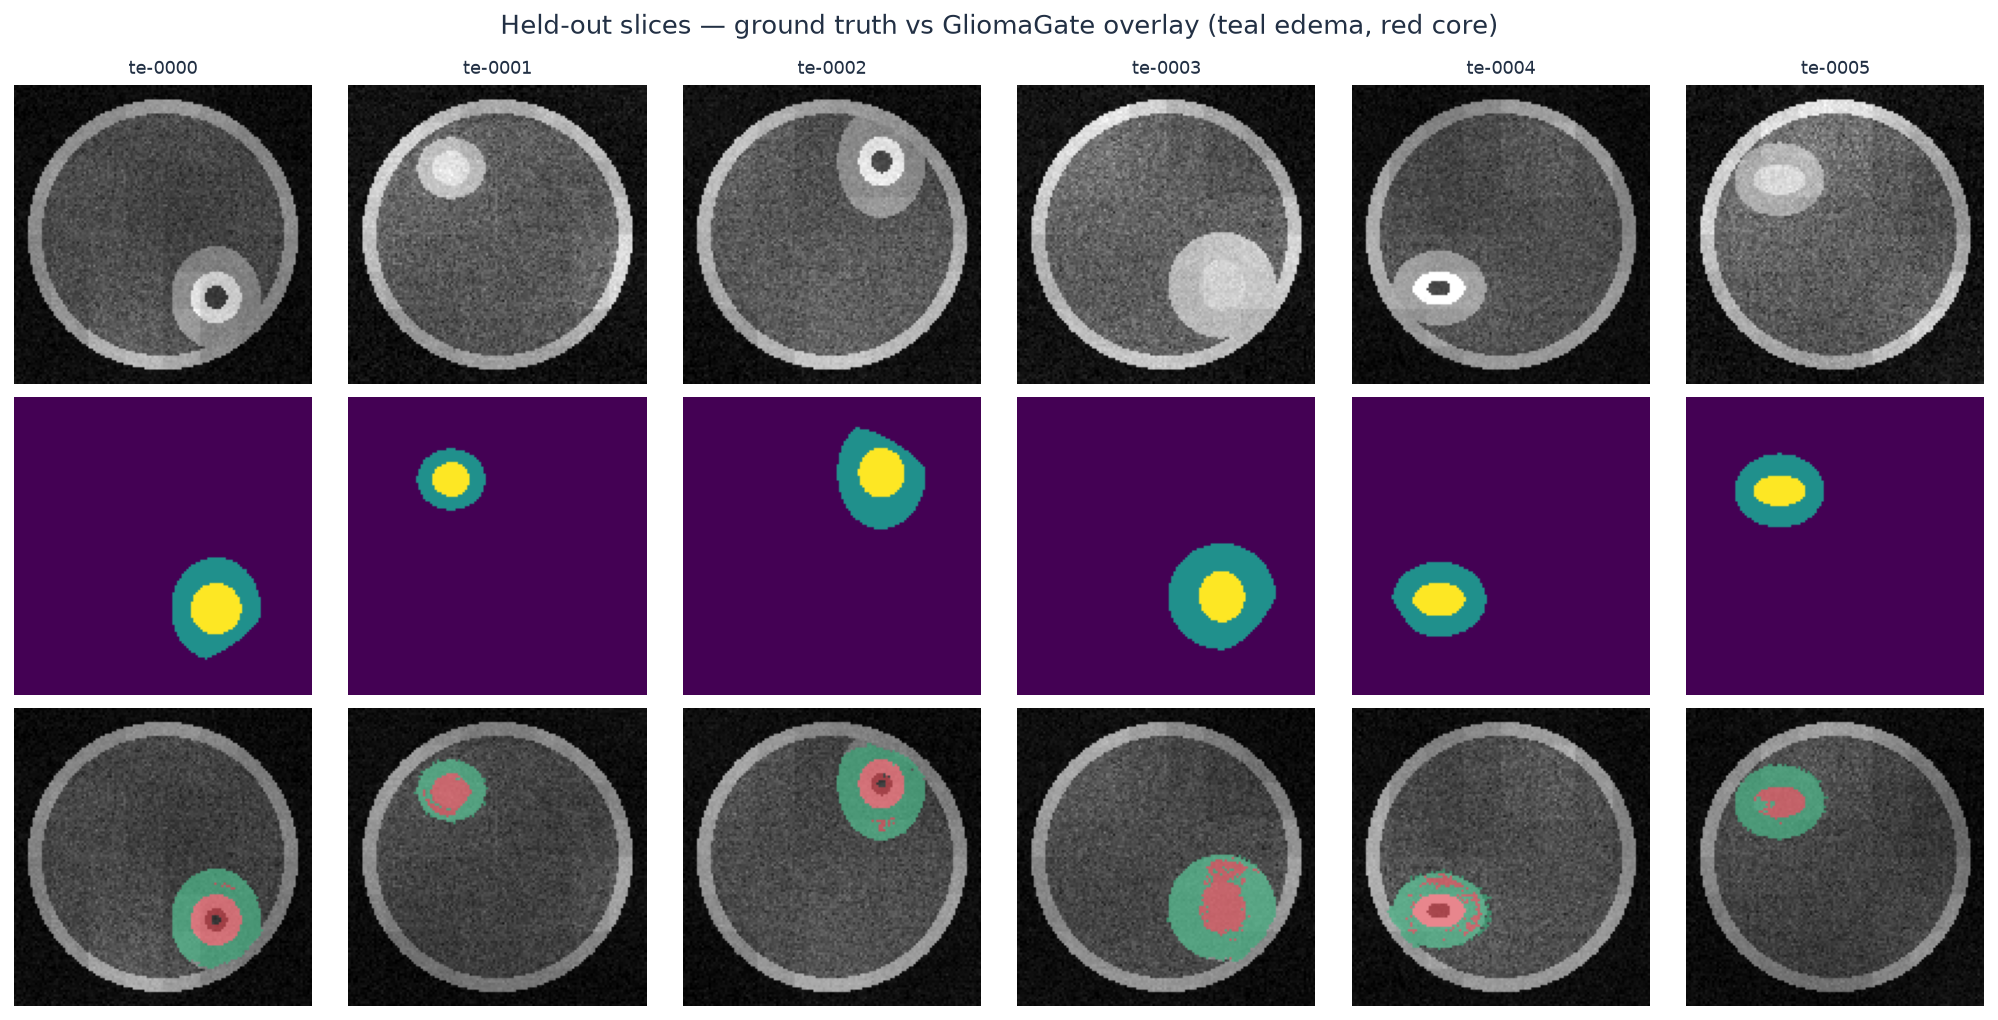

latency.png


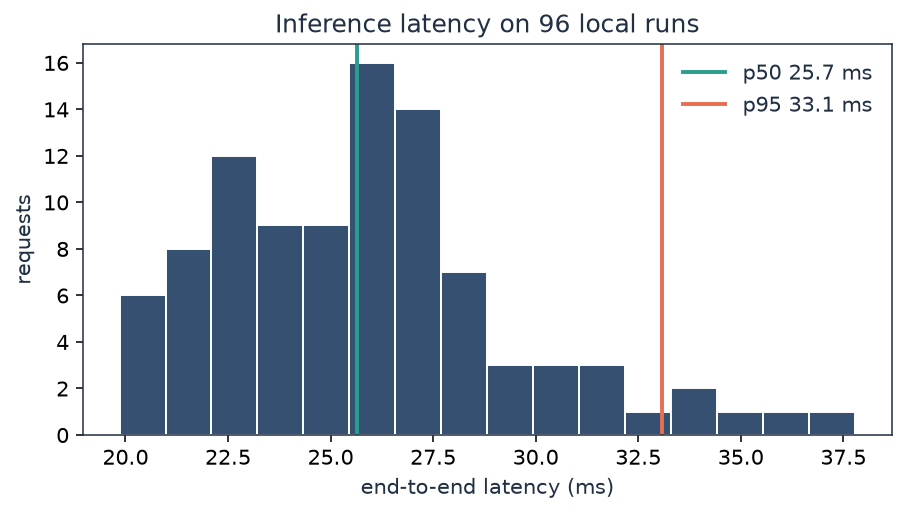

ledger.png


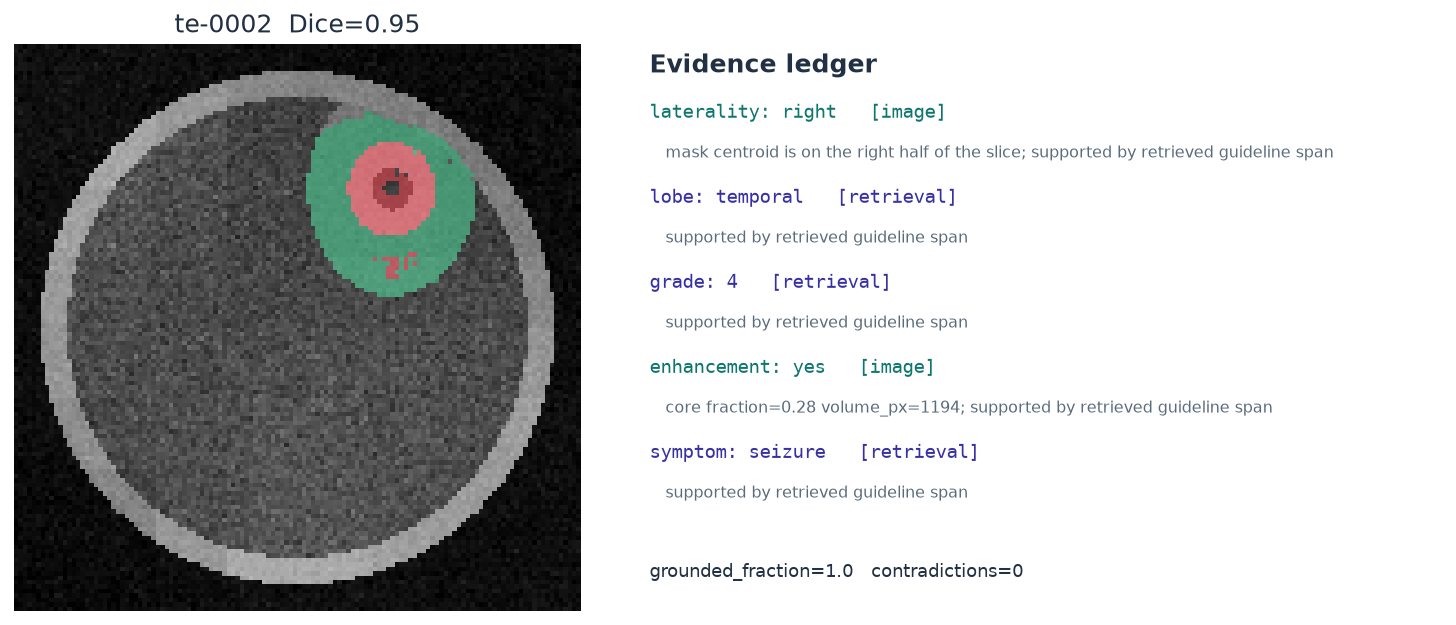

metrics_bars.png


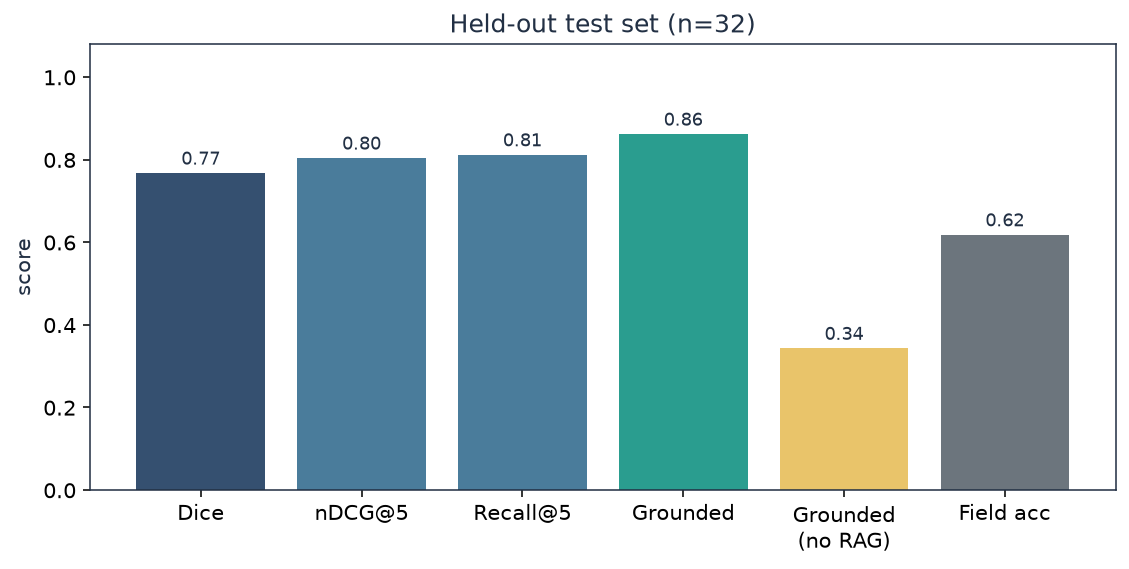

train_curves.png


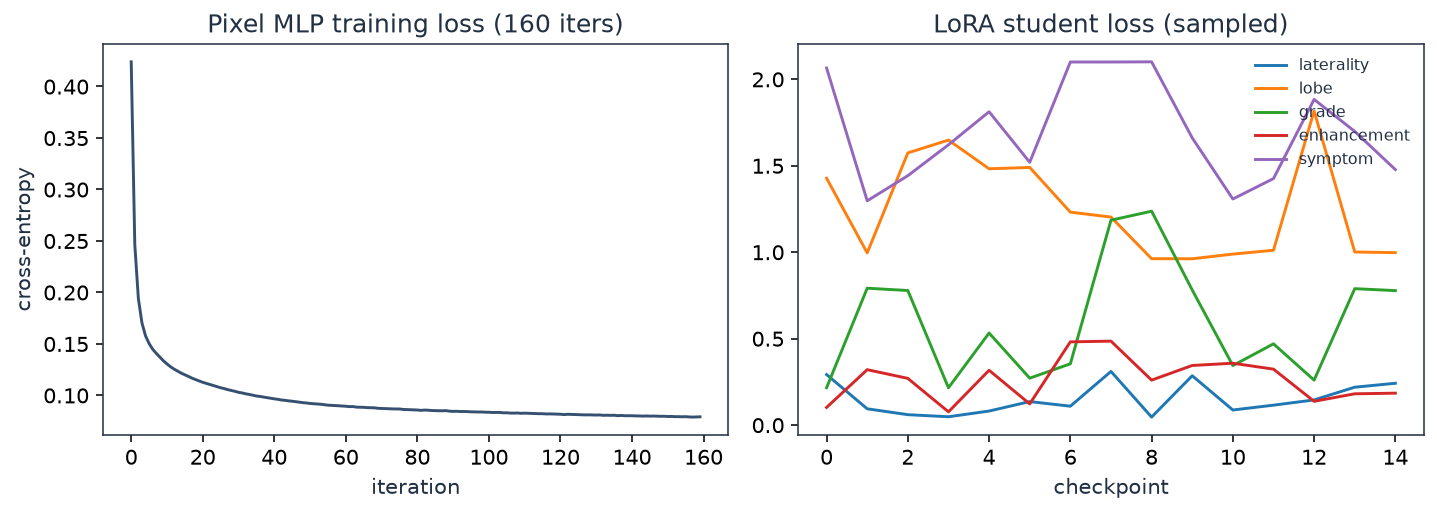

In [10]:
for p in sorted(FIGS.glob('*.png')):
    print(p.name)
    display(Image(filename=str(p), width=720))